# Case study: Ring‑hydroxylating Dioxygenases

This notebook demonstrates the **SDP Detection Pipeline** on the Pfam PF00848 family. The pipeline identifies specificity‑determining positions (SDPs) that discriminate among the natural functional subgroups present in the alignment.

### Pipeline overview
1. **Load & map positions** – parse MSA and extract residue numbers from headers.
2. **Cleanse** – remove gap‑rich columns and rows.
3. **MCA** – dimensionality reduction.
4. **Clustering** – single‑linkage with silhouette score selection.
5. **Random Forest** – feature importance using cluster labels as target.
6. **Select SDPs** – top *N* most important columns.
7. **Visualise** – word clouds, sequence logos, perceptual map.

<!-- After the automated pipeline, we manually filter sequences with known structures and visualise the SDPs in 3D. -->

## 1. Imports and data loading

In [1]:
# Ensure the package is installed (e.g., pip install -e . from the project root)
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sdp_detection_pipeline.io import load_msa, map_positions, build_profiles
from sdp_detection_pipeline.preprocessing import CleanseTransformer
from sdp_detection_pipeline.modeling import MCAClusterFeatureSelector
from sdp_detection_pipeline.visualization import (
    plot_cleanse_heatmaps,
    plot_pareto,
    plot_perceptual_map,
    generate_wordclouds,
    generate_logos,
)
from sklearn.pipeline import Pipeline

In [2]:
# Paths to the input files (relative to this notebook)
MSA_FILE = "pf00848-alignment.fasta"
METADATA_FILE = "pf00848-metadata.tsv"

# Load the MSA
raw_msa = load_msa(MSA_FILE)
print(f"Loaded alignment with {raw_msa.shape[0]} sequences and {raw_msa.shape[1]} columns.")

# Map sequence headers to residue positions
positions_map = map_positions(raw_msa)
print(f"Position mapping created for {len(positions_map)} sequences.")

Loaded alignment with 9381 sequences and 1225 columns.
Position mapping created for 9381 sequences.


## 2. Create and fit the pipeline

The pipeline combines cleansing and the MCA‑clustering‑RF selector.

In [3]:
pipeline = Pipeline([
    ("cleanse", CleanseTransformer(threshold=0.9, remove_lowercase=True)),
    ("sdp", MCAClusterFeatureSelector(
        cluster_method="single-linkage",
        min_clusters=3,
        rf_n_estimators=1000,
        random_state=42,
        top_n=3,                     # we want exactly the top‑3 SDPs
    ))
])

pipeline.fit(raw_msa)
print("Pipeline fitted.")

/Users/lucas/Desktop/Projects/sdp-detection-pipeline/sdp_detection_pipeline/preprocessing.py:42: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return X.replace(bad, np.nan)


Pipeline fitted.


## 3. Inspect the results

In [4]:
cleanse_step = pipeline.named_steps["cleanse"]
sdp_step = pipeline.named_steps["sdp"]

print(f"Kept columns after cleansing: {len(cleanse_step.kept_columns_)}")
print(f"Number of unique sequences (deduplicated): {sdp_step.unique_sequences_.shape[0]}")
print(f"Optimal number of clusters found: {len(set(sdp_step.labels_))}")
print(f"Silhouette score for chosen clustering: {np.max([s for s in [1]])}  # you can compute manually if needed")
print(f"Top selected columns (SDPs): {sdp_step.selected_columns_}")
print(f"Column importances:\n{sdp_step.column_importances_.to_string()}")

Kept columns after cleansing: 41
Number of unique sequences (deduplicated): 6469
Optimal number of clusters found: 3
Silhouette score for chosen clustering: 1  # you can compute manually if needed
Top selected columns (SDPs): [784, 982, 200]
Column importances:
column
784    0.119545
982    0.111677
200    0.098175
224    0.046007
987    0.040247
819    0.039941
204    0.037515
220    0.035530
186    0.033555
984    0.030184
825    0.029514
225    0.029069
834    0.026901
838    0.026037
216    0.025526
786    0.024412
845    0.023908
763    0.018724
851    0.017938
831    0.017536
853    0.017307
185    0.017194
829    0.016645
848    0.013990
841    0.012697
187    0.012293
789    0.011360
793    0.010978
816    0.009351
781    0.006269
811    0.005244
810    0.005204
815    0.004521
813    0.003633
814    0.003508
205    0.002160
799    0.000692


## 4. Generate visualisations

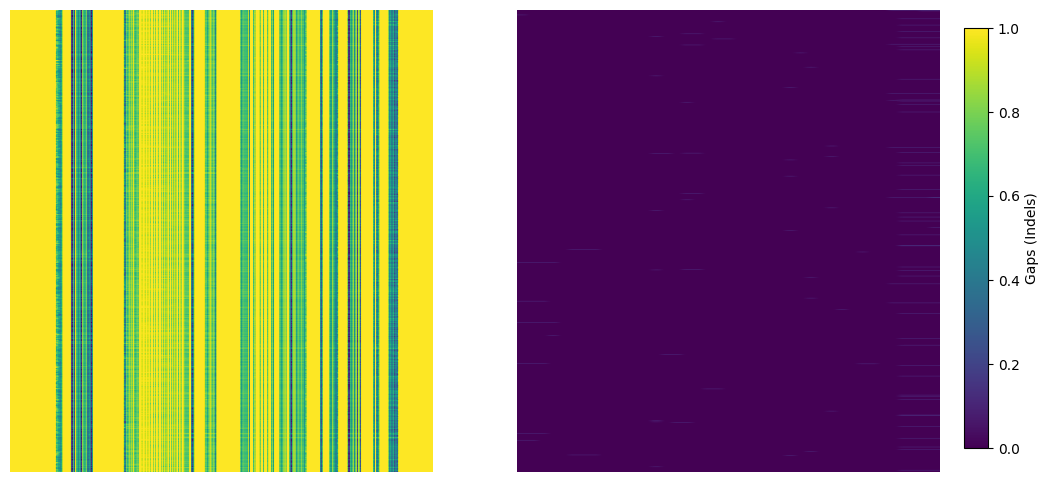

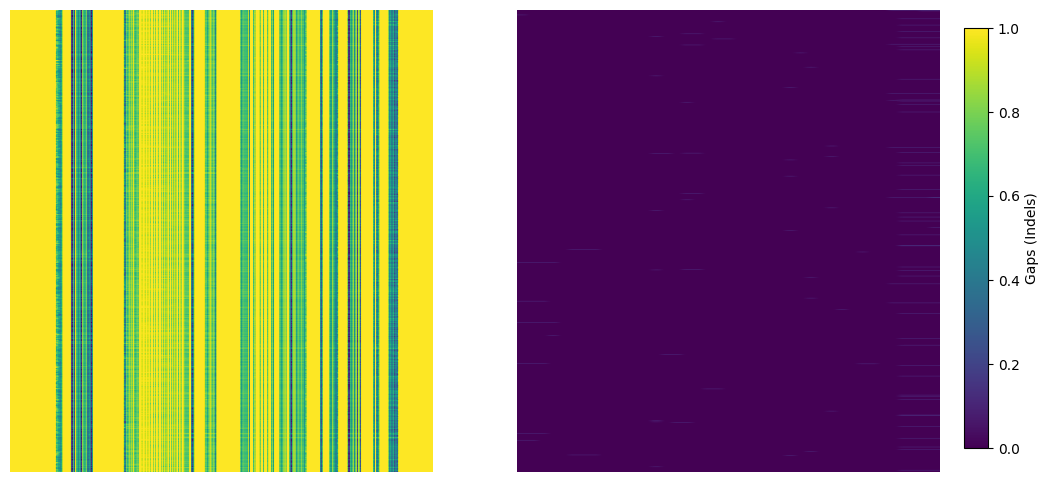

In [5]:
# Cleansing heatmaps
plot_cleanse_heatmaps(cleanse_step.dirty_, cleanse_step.clean_, show=True)

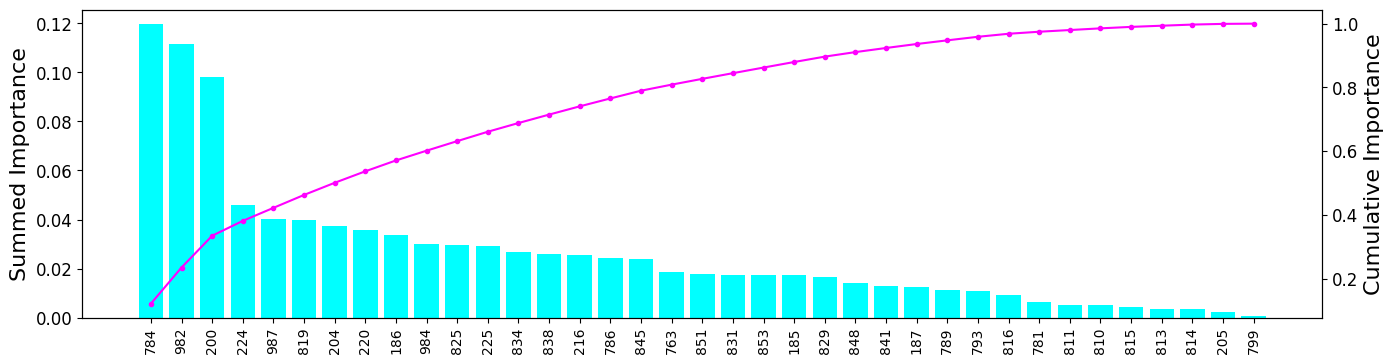

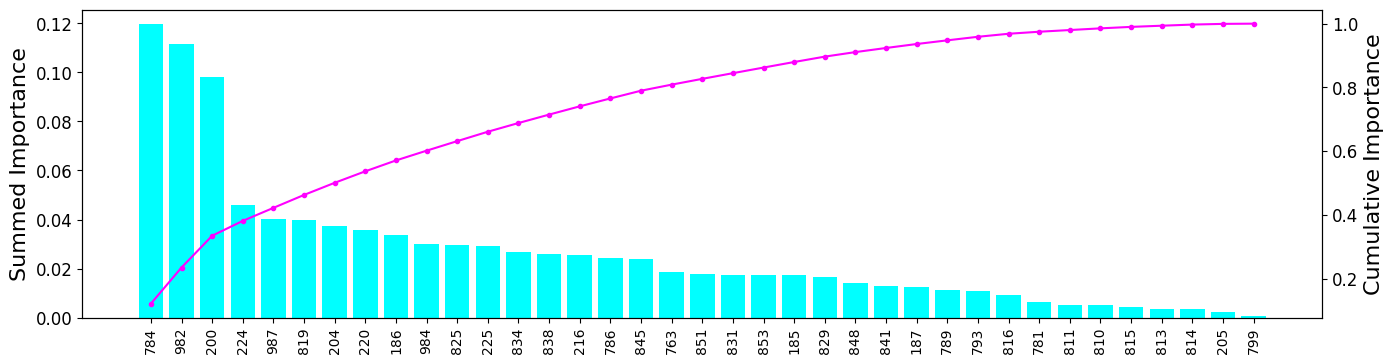

In [6]:
# Pareto chart of column importances
plot_pareto(sdp_step.column_importances_, show=True)

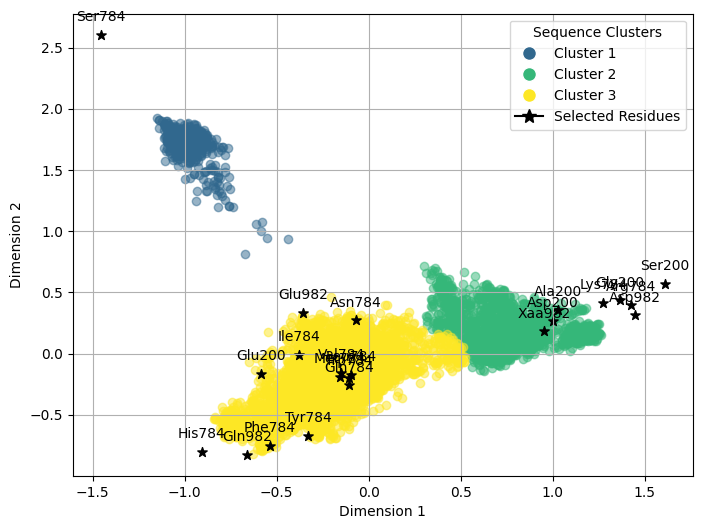

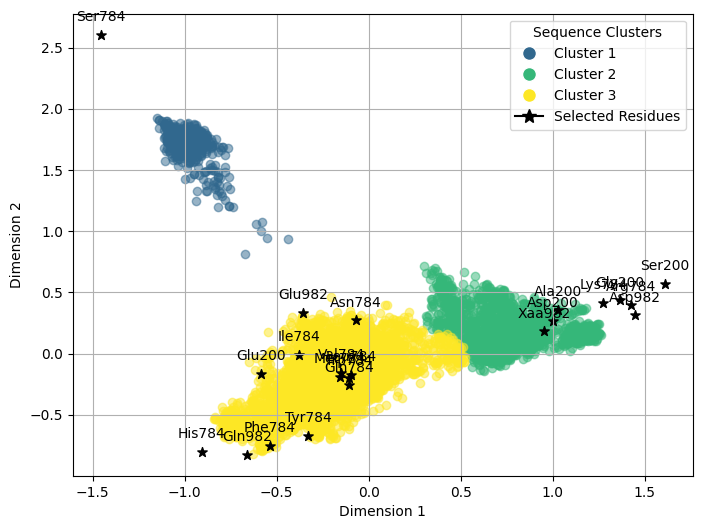

In [7]:
# Perceptual map (MCA plot with SDP residues)
plot_perceptual_map(
    sdp_step.mca_,
    sdp_step.unique_sequences_,
    sdp_step.coordinates_,
    sdp_step.labels_,
    sdp_step.selected_columns_,
    sdp_step.selected_feature_names_,
    show=True,
)

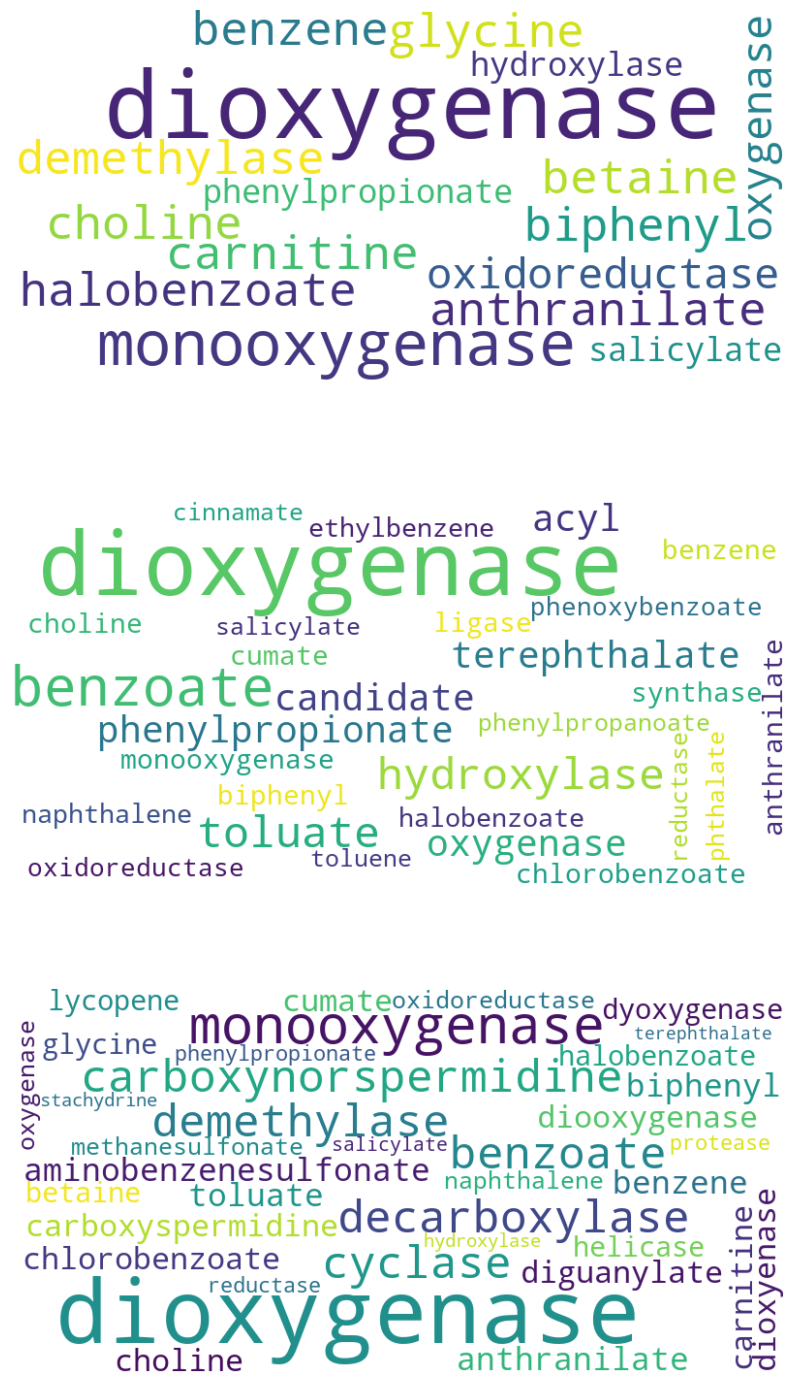

{1: 'anthranilate dioxygenase benzene dioxygenase biphenyl dioxygenase carnitine monooxygenase choline monooxygenase dioxygenase glycine/betaine demethylase halobenzoate dioxygenase oxidoreductase oxygenase phenylpropionate dioxygenase salicylate hydroxylase',
 2: 'acyl ligase acyl synthase anthranilate dioxygenase benzene dioxygenase benzoate dioxygenase benzoate oxygenase benzoate/toluate dioxygenase biphenyl dioxygenase candidate hydroxylase candidate/terephthalate dioxygenase chlorobenzoate dioxygenase choline monooxygenase cumate dioxygenase dioxygenase ethylbenzene dioxygenase halobenzoate dioxygenase hydroxylase naphthalene dioxygenase oxidoreductase oxygenase phenoxybenzoate dioxygenase phenylpropanoate dioxygenase phenylpropionate dioxygenase phenylpropionate/cinnamate dioxygenase phthalate dioxygenase reductase salicylate hydroxylase terephthalate dioxygenase toluate dioxygenase toluate/benzoate dioxygenase toluene/benzoate dioxygenase',
 3: 'aminobenzenesulfonate dioxygenase

In [8]:
# Word clouds (requires the UniProt TSV metadata)
generate_wordclouds(
    sdp_step.input_index_,
    sdp_step.unique_sequences_,
    sdp_step.labels_,
    metadata=METADATA_FILE,
    show=True,
)

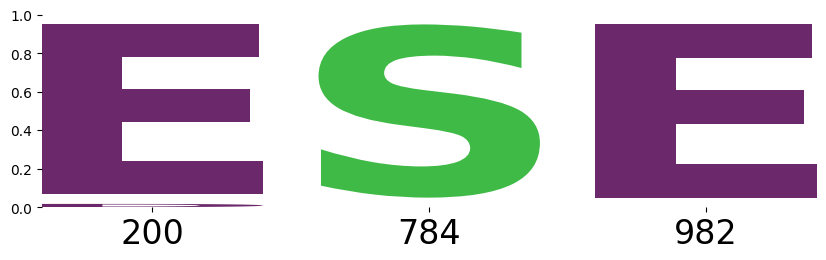

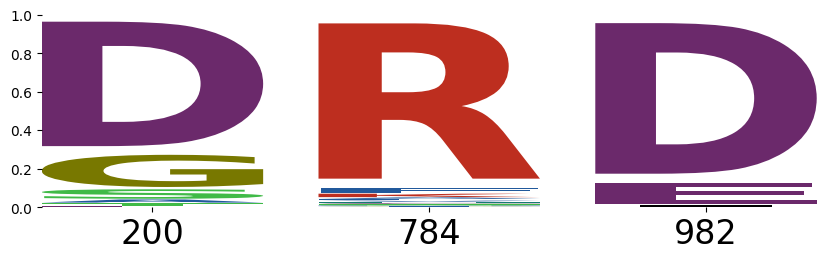

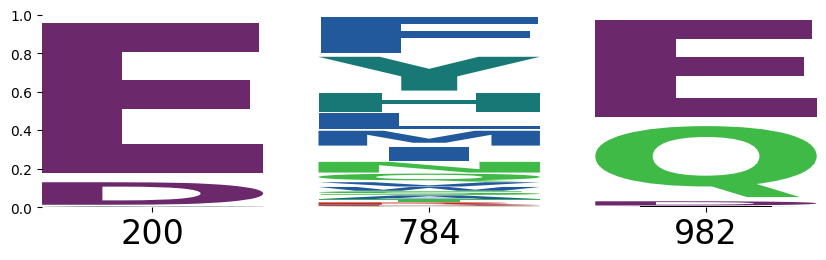

{1:             D         E    S
 200  0.018325  0.981675  0.0
 784  0.000000  0.000000  1.0
 982  0.000000  1.000000  0.0,
 2:             -         A         C         D         E         F         G  \
 200  0.000000  0.018029  0.000000  0.718149  0.005409  0.000000  0.185697   
 784  0.000601  0.008413  0.004207  0.000000  0.000601  0.032452  0.001202   
 982  0.010817  0.000000  0.000000  0.868990  0.120192  0.000000  0.000000   
 
            H         I         K         L         M         N         Q  \
 200  0.00000  0.000000  0.000000  0.000000  0.000000  0.000601  0.000000   
 784  0.00601  0.003005  0.019832  0.008413  0.003005  0.000000  0.003606   
 982  0.00000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
 
             R         S         T        V         Y  
 200  0.000000  0.054688  0.017428  0.00000  0.000000  
 784  0.896034  0.003005  0.003005  0.00601  0.000601  
 982  0.000000  0.000000  0.000000  0.00000  0.000000  ,
 3:             -       

In [9]:
# Sequence logos for each cluster
generate_logos(
    sdp_step.unique_sequences_,
    sdp_step.labels_,
    sdp_step.selected_columns_,
    show=True,
)

## 5. Build the SDP profile table

The profile shows the amino acid and residue number at each SDP for every original sequence.

In [10]:
profiles = build_profiles(raw_msa, positions_map, sdp_step.selected_columns_)
profiles.head(10)

,200,784,982
A0A1V1ZE67_9FLAO/178-361,Glu203,Asn281,Glu319
A0A0J1DCU0_9BURK/170-416,Asp214,Arg314,Asp360
J2WKD9_9SPHN/182-387,Glu207,His301,Glu345
A0A1Q3AVG0_CEPFO/233-414,Asp258,Asn331,Glu373
A0A5N0VGT3_9PSEU/179-385,Glu205,Trp299,Gln342
A0A2M8QHP4_9SPHN/170-438,Gly217,Leu326,Asp373
A0A3N7F1M7_POPTR/242-370,Asp266,Asn339,-
A0A085TXN7_9RHOB/198-393,Glu224,Leu306,Glu351
A0A1G9KK55_9GAMM/195-391,Glu221,Met303,Glu348
A0A287XI26_HORVV/179-273,Asp205,-,-


## 6. Manual steps – sequences with known structures

The following steps are specific to this case study and not part of the pipeline.

In [11]:
# UniProt entry names for which a PDB structure is available
known_structure = [
    'TPDA2_COMSP',
    'BPHA1_RHOJR',
    'NDOB_PSEU8',
    'NDOB_PSEPU',
    'NAGG_RALSP',
    'CNTA_ACIB2',
    'BNZA_PSEP1',
    'BPHA_PARXL',
    'BPHA_COMTE',
]

# Filter the profile DataFrame
have_structure = [h for h in profiles.index if h.split('/')[0] in known_structure]
filtered_profiles = profiles.loc[have_structure]
filtered_profiles

,200,784,982
BPHA_PARXL/183-451,Ser229,Arg340,Asp387
BPHA1_RHOJR/174-441,Ser220,Arg330,Asp377


<!-- ## 7. Visualise SDPs in a 3D structure

We use `nglview` to highlight the identified SDPs on the structure of biphenyl dioxygenase (PDB 1ULI). -->

In [13]:
# import nglview as nv

# pdb_id = '1ULI'
# view = nv.show_pdbid(pdb_id)
# view.update_representation(opacity=0.5)

# sdps = tuple(sdp_step.selected_columns_)  # (220, 330, 377) in this case
# chains = ('A', 'C', 'E')

# selection_str = ":{} and ( {} or {} or {} )"
# for chain in chains:
#     view.add_representation('ball+stick', selection=selection_str.format(chain, *sdps), color='black')
#     view.add_representation('label', selection=selection_str.format(chain, *sdps), color='red')

# view